In [31]:
import numpy as np
import matplotlib.pyplot as plt  
import scipy.stats as sps

In [32]:
LAM_PLUS  = 1.2   
LAM_MINUS = 1.5
Q_ASK=Q_BID  = 10   

MU    = LAM_PLUS - LAM_MINUS   
SIGMA2 = LAM_PLUS + LAM_MINUS  
SIGMA = np.sqrt(SIGMA2)


## Q1.2.3.0- Simulation des deux files:

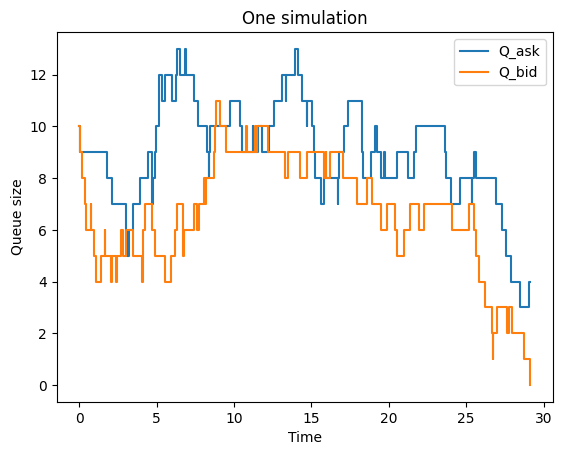

Temps final : 29.14980930187952


In [33]:
def Files(lambd_plus, lambd_minus, Q_ask, Q_bid):
    t = 0
    times = [t]
    ask_vals = [Q_ask]
    bid_vals = [Q_bid]

    new_lambd = 2 * (lambd_plus + lambd_minus)

    while Q_ask > 0 and Q_bid > 0:
        t += np.random.exponential(1 / new_lambd)
        U = np.random.uniform(0, new_lambd)

        if U < lambd_plus:
            Q_ask += 1
        elif U < lambd_plus + lambd_minus:
            Q_ask -= 1
        elif U < lambd_plus + lambd_minus + lambd_plus:
            Q_bid += 1
        else:
            Q_bid -= 1

        times.append(t)
        ask_vals.append(Q_ask)
        bid_vals.append(Q_bid)

    return times, ask_vals, bid_vals, t, (Q_ask == 0)


times, ask_vals, bid_vals, T, ask_empty = Files(LAM_PLUS, LAM_MINUS, Q_ASK, Q_BID)


plt.figure()
plt.step(times, ask_vals, where='post', label='Q_ask')
plt.step(times, bid_vals, where='post', label='Q_bid')
plt.xlabel("Time")
plt.ylabel("Queue size")
plt.title("One simulation")
plt.legend()
plt.show()

print("Temps final :", T)


Question 1.2.3:  On simule deux files indépendantes, avec des arrivées à taux constant et des départs à taux constant qui vaut 1.2 pour les arrivées et 1.5 pour les départs. On regarde le premier temps d'atteinte de 0 peu importe la file, et on garde en mémoire les différentes valeurs qu'ont pris les files bid et ask au cours des évenements, le temps d'occurence des différents évènements, et le temps d'atteinte de 0 pour une des files. 

In [34]:
def deux_files(init, lam_plus, lam_minus):
    t = 0
    A = init
    V = init
    # Tableaux pour stocker les données de temps, ventes et achats
    temps = [t]
    ventes = [A]
    achats = [V]

    # Simulation jusqu'à ce que l'une des files atteigne 0
    while A > 0 and V > 0:
        # Calcul du temps jusqu'au prochain événement
        t += np.random.exponential(1 / (2 * (lam_plus + lam_minus)))
        
        # Détermination de l'événement (vente ou achat)
        if np.random.rand() < 0.5:

            # Si c'est une vente, on décide si c'est une augmentation ou diminution de la file de vente
            if np.random.rand() < lam_plus / (lam_plus + lam_minus):
                A += 1
            else:
                A -= 1
        else:
            # Si c'est un achat, on décide si c'est une augmentation ou diminution de la file d'achat
            if np.random.rand() < lam_plus / (lam_plus + lam_minus):
                V += 1
            else:
                V -= 1

        # Stockage des données après chaque événement
        temps.append(t)
        ventes.append(A)
        achats.append(V)

    return t, temps, ventes, achats

On fait de même mais en ne regardant qu'une seule file cette fois ci, et en gardant en mémoire le temps l'occurence de chaque incrémentation, ou diminution, et l'évolution de la file à chaque evenement, et finalemenet le temps d'atteinte de 0. 

In [35]:
def une_file(init, lam_plus, lam_minus):
    t = 0.0
    q = init
    temps = [t]
    valeurs = [q]

    while q > 0:
        t += np.random.exponential(1 / (lam_plus + lam_minus))
        if np.random.rand() < lam_plus / (lam_plus + lam_minus):
            q += 1
        else:
            q -= 1
        temps.append(t)
        valeurs.append(q)

    return temps, valeurs, t

   

1.2.3.2: On souhaite simuler la distribution des temps d'atteinte de zéro par l'une des files (ASK) en la superposant à une simulation brownienne discrétisée:

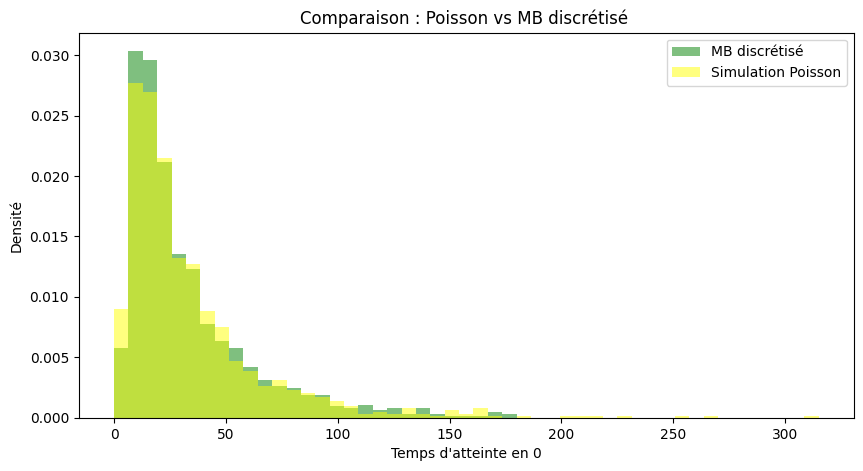

In [36]:
mu=LAM_PLUS-LAM_MINUS
sigma=np.sqrt(LAM_PLUS+LAM_MINUS)
def deux_files(init, lam_plus, lam_minus):
    t = 0
    A = init
    V = init
    temps = [t]
    ventes = [A]
    achats = [V]

    while A > 0 and V > 0:
        t += np.random.exponential(1 / (2 * (lam_plus + lam_minus)))
        if np.random.rand() < 0.5:
            if np.random.rand() < lam_plus / (lam_plus + lam_minus):
                A += 1
            else:
                A -= 1
        else:
            if np.random.rand() < lam_plus / (lam_plus + lam_minus):
                V += 1
            else:
                V -= 1

        temps.append(t)
        ventes.append(A)
        achats.append(V)

    return t, temps, ventes, achats


def une_file(init, lam_plus, lam_minus):
    t = 0.0
    q = init
    temps = [t]
    valeurs = [q]

    while q > 0:
        t += np.random.exponential(1 / (lam_plus + lam_minus))
        if np.random.rand() < lam_plus / (lam_plus + lam_minus):
            q += 1
        else:
            q -= 1
        temps.append(t)
        valeurs.append(q)

    return temps, valeurs, t


def moyenne_temps_atteinte(N, init, lam_plus, lam_minus):
    tt = []
    for _ in range(N):
        _, _, tau = une_file(init, lam_plus, lam_minus)
        tt.append(tau)
    tt = np.array(tt)
    m = np.mean(tt)
    s = np.std(tt, ddof=1)
    ic = 1.96 * s / np.sqrt(N)
    return m, m - ic, m + ic


def brownien(init, mu, sigma, dt=0.01, tmax=1000):
    t = 0
    x = init
    temps = [t]
    valeurs = [x]

    while x > 0 and t < tmax:
        x = x + mu * dt + sigma * np.sqrt(dt) * np.random.randn()
        t += dt
        temps.append(t)
        valeurs.append(x)

    return temps, valeurs
# Simulation
taus_ask=[une_file(Q_ASK,LAM_PLUS,LAM_MINUS)[2] for _ in range(N)]
taus_bm_discret = [brownien(Q_ASK, mu, sigma)[0][-1] for _ in range(N)]

# Comparaison
bins = np.linspace(0, max(max(taus_ask), max(taus_bm_discret)), 50)

plt.figure(figsize=(10, 5))
plt.hist(taus_bm_discret, bins=bins, density=True, alpha=0.5, color='green',   label='MB discrétisé')
plt.hist(taus_ask,        bins=bins, density=True, alpha=0.5, color='yellow', label='Simulation Poisson')
plt.xlabel("Temps d'atteinte en 0")
plt.ylabel("Densité")
plt.title("Comparaison : Poisson vs MB discrétisé ")
plt.legend()
plt.show()


Puis à la distribution théorique brownienne :

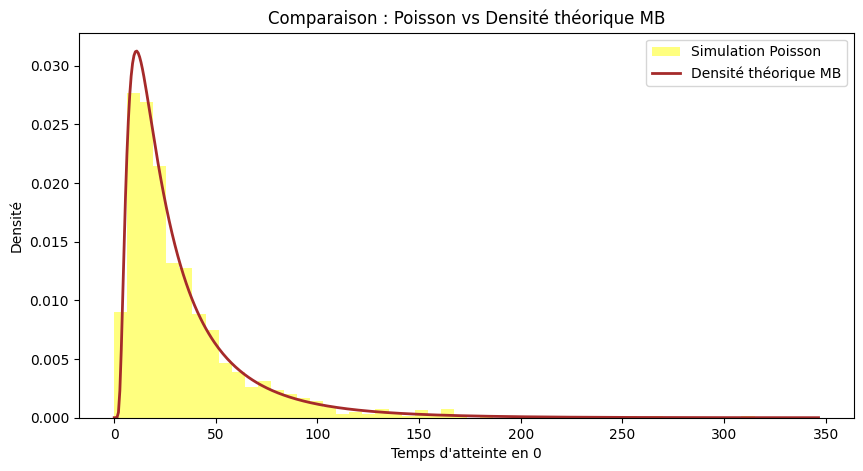

In [37]:
t_grid = np.linspace(0.1, max(taus_ask)*1.1, 500)
pdf    = (Q_ASK / (sigma * np.sqrt(2*np.pi*t_grid**3))) \
         * np.exp(-(Q_ASK + mu*t_grid)**2 / (2*sigma**2*t_grid))
        
plt.figure(figsize=(10, 5))
plt.hist(taus_ask,bins=bins, density=True, alpha=0.5, color='yellow', label='Simulation Poisson')
plt.plot(t_grid, pdf, color='brown', lw=2, label='Densité théorique MB')

plt.xlabel("Temps d'atteinte en 0")
plt.ylabel("Densité")
plt.title("Comparaison : Poisson vs Densité théorique MB")
plt.legend()
plt.show()


1.2.3.3: On veut simuler le temps moyen d’atteinte de zéro d’une des file d’attente et calculer un intervalle
de confiance.
On simule alors N trajectoires et one calcule la moyenne et de l'intervalle de confiance à 95% pour le temps d'atteinte de 0

In [38]:
def moyenne_temps_atteinte(N, init, lam_plus, lam_minus):

    tt = []
    # Boucle pour simuler N fois et stocker les temps d'atteinte de 0
    for _ in range(N):
        # On simule une file et garder le temps d'atteinte de 0
        _, _, tau = une_file(init, lam_plus, lam_minus)
        tt.append(tau)
    tt = np.array(tt)

    # Calcul de la moyenne, de l'écart-type et de l'intervalle de confiance à 95%
    m = np.mean(tt)
    s = np.std(tt, ddof=1)
    ic = 1.96 * s / np.sqrt(N)
    # On retourne la moyenne et l'intervalle de confiance
    return m, m - ic, m + ic

On affiche de la valeur moyenne et de l'intervalle de confiance sur N = 1000 essais.

In [39]:
N = 1000
m, m_moins, m_plus = moyenne_temps_atteinte(N, init=10, lam_plus=1.2, lam_minus=1.5)
print(f"Le temps moyen d'atteinte de 0 est: {m:.2f}. L'intervalle de confiance à 95% est [{m_moins:.2f}, {m_plus:.2f}])")

Le temps moyen d'atteinte de 0 est: 32.32. L'intervalle de confiance à 95% est [30.48, 34.16])


1.2.3.4 : On simula la moyenne de premier temps d'atteinte en 0 en fonction des tailles initiales de chaque file, pour ce faire on fait varier les tailles initiales des files entre 1 et 20 :

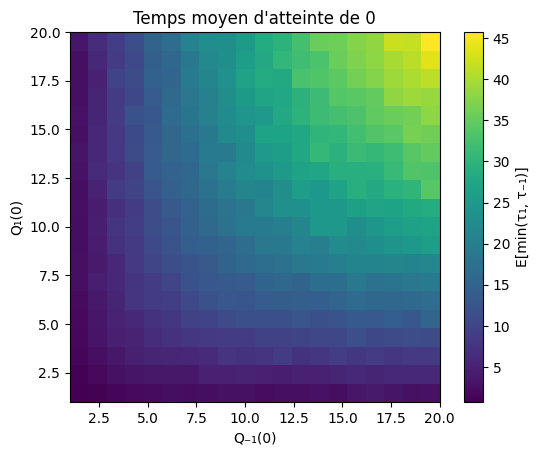

In [40]:
N4 = 500
Q_range=np.arange(1,21)
moyennes=np.zeros((len(Q_range),len(Q_range)))

for i, Q1 in enumerate(Q_range):
    for j, Q2 in enumerate(Q_range):
       taus=[]
       for _ in range(N4):
          times, ask_vals, bid_vals, T, ask_empty = Files(LAM_PLUS, LAM_MINUS, Q1, Q2)
          taus.append(T)
          moyennes[i,j]=np.mean(taus)
          

plt.imshow(moyennes, origin='lower',
           extent=[Q_range[0], Q_range[-1], Q_range[0], Q_range[-1]])
plt.colorbar(label="E[min(τ₁, τ₋₁)]")
plt.xlabel("Q₋₁(0)")
plt.ylabel("Q₁(0)")
plt.title("Temps moyen d'atteinte de 0")
plt.show()       



1.2.3.5:  On simule la probabilité que 𝑄1 (0) touche zéro avant 𝑄−1(0) en fonction de 𝑄1 (0) et 𝑄−1(0).
On simule N fois les deux files et on compte combien de fois la file de vente atteint 0 avant la file d'achat

In [41]:
def prob_Q1(N, init, lam_plus, lam_moins):
    inc = 0
    for _ in range(N):
        _, _, ventes, achats = deux_files(init, lam_plus, lam_moins)

        # On trouve l'index où l'une des files atteint 0
        for i in range(1, len(ventes)):
            if ventes[i] == 0:
                inc += 1
                break
            elif achats[i] == 0:
                break
    
    proba = inc / N
    return proba

Question 1.2.4: Processus de Hawkes 
1.2.4.1: Simuler une file d’attente de Hawkes et approcher son intensité stationnaire 𝜆−


1.2.4.2: Estimer la distribution des temps d’atteinte de zero par cette file d’attente.
Simulation pour estimer la probabilité que la file de vente atteigne 0 avant la file d'achat


In [45]:

def hawkes_une_file(init, mu_plus, mu_moins, alpha, beta):
    # Initialisation des variables
    t = 0
    q = init
    z_plus = 0
    z_moins = 0
    lam_plus = mu_plus
    temps = [t]
    tailles = [q]
    intensites_moins = []


    # Simulation jusqu'à ce que la file atteigne 0
    while q > 0:
        # Calcul des intensités à l'instant t
        lam_minus = mu_moins - alpha * z_plus + alpha * z_moins
        # Intensité totale
        total = lam_plus + lam_minus

        # temps jusqu'au prochain événement
        dt = np.random.exponential(1 / total)

        # Mise à jour des intensités en fonction du temps écoulé
        z_plus *= np.exp(-beta * dt)
        z_moins *= np.exp(-beta * dt)

        # Incrémentation du temps
        t += dt
   
    # Détermination de l'événement (augmentation ou diminution de la file)
        if np.random.random() < lam_plus / total:
            q += 1
            z_plus += 1
        else:
            q -= 1
            z_moins += 1
    # Stockage des données après chaque événement
        temps.append(t)
        tailles.append(q)
        intensites_moins.append(lam_minus)

    return t, temps, tailles, intensites_moins

1.2.4.3
On commence par estimer la distribution des temps d’atteinte de zero pour les deux files d’attente couplées. 

In [43]:
def temps_atteinte_zero_deux_files(init_achat, init_vente, mu_plus, mu_moins, alpha, beta):

    t = 0.0
    achat = int(init_achat)
    vente = int(init_vente)

    z_aug_achat = 0.0
    z_dim_achat = 0.0
    z_aug_vente = 0.0
    z_dim_vente = 0.0

    while achat > 0 and vente > 0:

        lam_bid = ( mu_moins - alpha * (z_aug_achat + z_aug_vente) + alpha * (z_dim_achat + z_dim_vente))

        lam_ask = (mu_moins  - alpha * (z_aug_vente + z_aug_achat)+ alpha * (z_dim_vente + z_dim_achat))
        
        total = 2 * mu_plus + lam_bid + lam_ask

        dt = np.random.exponential(1 / total)

        noyau = np.exp(-beta * dt)

        z_aug_achat *= noyau
        z_dim_achat *= noyau
        z_aug_vente *= noyau
        z_dim_vente *= noyau

        t += dt

        u = np.random.random() * total

        if u < mu_plus:

            achat += 1
            z_aug_achat += 1

        elif u < 2 * mu_plus:

            vente += 1
            z_aug_vente += 1

        elif u < 2 * mu_plus + lam_bid:

            achat -= 1
            z_dim_achat += 1

        else:
            vente -= 1
            z_dim_vente += 1

    return t

1.2.4.4 Simulation de plusieurs trajectoires pour estimer la distribution des temps d'atteinte de 0 et affichage de l'historiogramme

In [44]:
n = 1000
T = np.empty(n)
# Simulation de n fois et stockage des temps d'atteinte de 0 pour la première des deux files        
for i in range(n):
    T[i] = temps_atteinte_zero_deux_files(
        init_achat=10,
        init_vente=10,
        mu_plus=1,
        mu_moins=1.2,
        alpha=0.4,
        beta=1
    )

# Affichage de l'histogramme des temps d'atteinte de 0
plt.hist(T, bins=40, density=True, alpha=0.7)
plt.xlabel("Temps d'atteinte de 0")
plt.ylabel("Densité empirique")
plt.title("Distribution des temps d'atteinte de 0\n(par la première des deux files)")
plt.show()

ValueError: scale < 0

1.2.4.5

TypeError: object of type 'function' has no len()

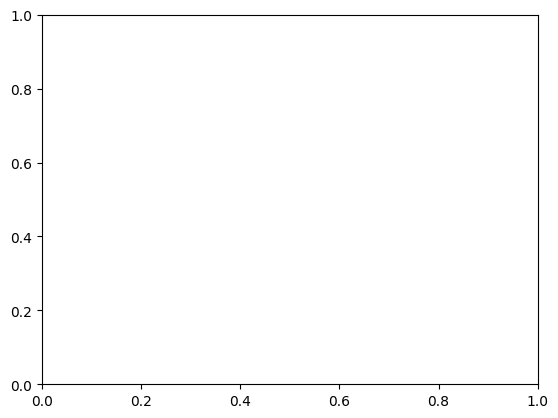

In [ ]:

# Une file Hawkes
plt.hist( hawkes_une_file, bins=40, density=True, alpha=0.4, label="1 file Hawkes")

# Deux files Hawkes couplées
plt.hist(temps_atteinte_zero_deux_files, bins=40, density=True,alpha=0.4, label="2 files Hawkes couplées"
)

plt.xlabel("Temps d'atteinte de 0")
plt.ylabel("Densité empirique")

plt.title("Comparaison des distributions des temps d'atteinte de zéro")

plt.legend()

plt.show()

1.2.5 : Deuxième limite 

1.2.5.1 : On va simuler la distribution de la deuxième limite ASK conditionnement au fait que la première ait touché 0 :

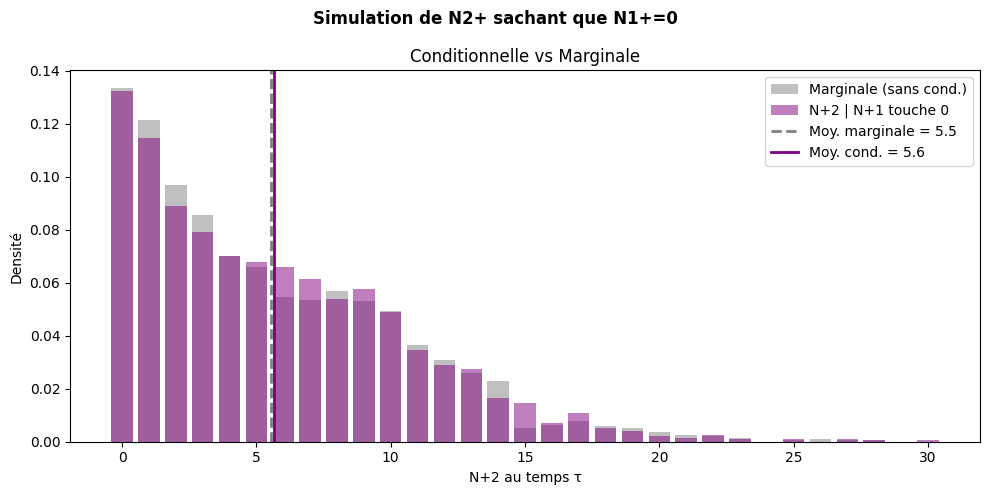

In [47]:
MU_PLUS = 1.0
MU_MINUS = 1.1
ALPHA = 0.3
BETA = 0.6
Q2_0 = 10     
N = 2000


def simulate_second_limit(lam_plus, lam_minus, Q2_0, T_stop):
    Q    = Q2_0
    t    = 0.0
    rate = lam_plus + lam_minus
    p_up = lam_plus / rate
    while True:
        dt = np.random.exponential(1.0 / rate)
        if t + dt > T_stop:
            break
        t += dt
        Q += 1 if np.random.random() < p_up else -1
        Q  = max(0, Q)  
    return Q



N2_vals_a = []
for _ in range(N):
    T, _, _, _ = hawkes_une_file(Q_ASK, MU_PLUS, MU_MINUS, ALPHA, BETA)
    N2_vals_a.append(simulate_second_limit(LAM_PLUS, LAM_MINUS, Q2_0, T))

N2_marginal = []
for _ in range(N):
    T, _, _, _ = hawkes_une_file(Q_ASK, MU_PLUS, MU_MINUS, ALPHA, BETA)
    N2_marginal.append(simulate_second_limit(LAM_PLUS, LAM_MINUS, Q2_0, T))

bins = np.arange(0, max(max(N2_vals_a), max(N2_marginal)) + 2) - 0.5
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Simulation de N2+ sachant que N1+=0", fontweight="bold")

ax.hist(N2_marginal, bins=bins, density=True, color="gray",   alpha=0.5,
        rwidth=0.8, label="Marginale (sans cond.)")
ax.hist(N2_vals_a,   bins=bins, density=True, color="purple", alpha=0.5,
        rwidth=0.8, label="N+2 | N+1 touche 0")
ax.axvline(np.mean(N2_marginal), color="gray",   lw=2, ls="--",
           label=f"Moy. marginale = {np.mean(N2_marginal):.1f}")
ax.axvline(np.mean(N2_vals_a),   color="purple", lw=2,
           label=f"Moy. cond. = {np.mean(N2_vals_a):.1f}")
ax.set(xlabel="N+2 au temps τ", ylabel="Densité",
       title="Conditionnelle vs Marginale")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Puis conditionnement à l'extinction de la première limite bid :

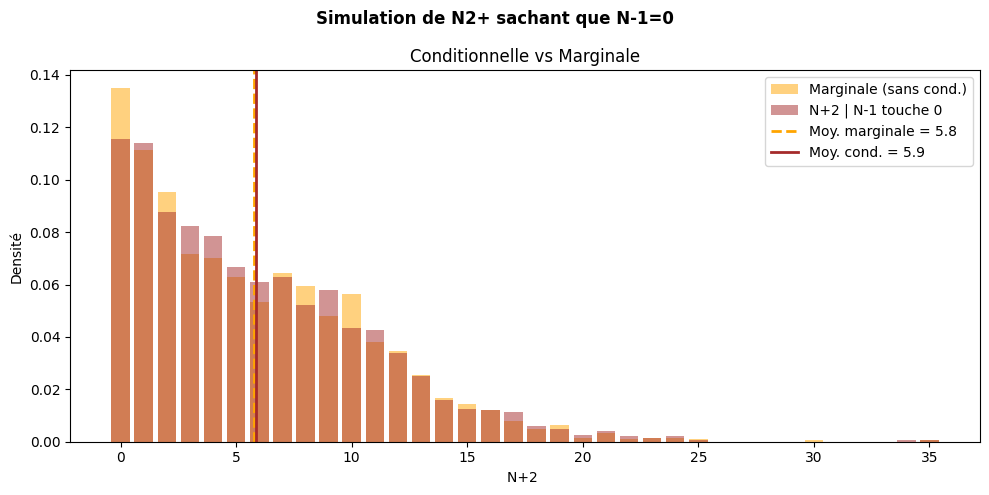

In [48]:
N2_vals_b= []
for _ in range(N):
    T, _, _, _ = hawkes_une_file(Q_ASK, MU_PLUS, MU_MINUS, ALPHA, BETA)
    N2_vals_b.append(simulate_second_limit(LAM_PLUS, LAM_MINUS, Q2_0, T))

N2_marginal = []
for _ in range(N):
    T, _, _, _ = hawkes_une_file(Q_BID, MU_PLUS, MU_MINUS, ALPHA, BETA)
    N2_marginal.append(simulate_second_limit(LAM_PLUS, LAM_MINUS, Q2_0, T))

bins = np.arange(0, max(max(N2_vals_a), max(N2_marginal)) + 2) - 0.5
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Simulation de N2+ sachant que N-1=0", fontweight="bold")

ax.hist(N2_marginal, bins=bins, density=True, color="orange",   alpha=0.5,
        rwidth=0.8, label="Marginale (sans cond.)")
ax.hist(N2_vals_b,   bins=bins, density=True, color="brown", alpha=0.5,
        rwidth=0.8, label="N+2 | N-1 touche 0")
ax.axvline(np.mean(N2_marginal), color="orange",   lw=2, ls="--",
           label=f"Moy. marginale = {np.mean(N2_marginal):.1f}")
ax.axvline(np.mean(N2_vals_b),   color="brown", lw=2,
           label=f"Moy. cond. = {np.mean(N2_vals_b):.1f}")
ax.set(xlabel="N+2 ", ylabel="Densité",
       title="Conditionnelle vs Marginale")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

1.2.5.2 : Maintenant, on reproduit le travail de la question précedente mais en tenant compte de la croissance des deuxièmes limites( cf rapport):

KeyboardInterrupt: 

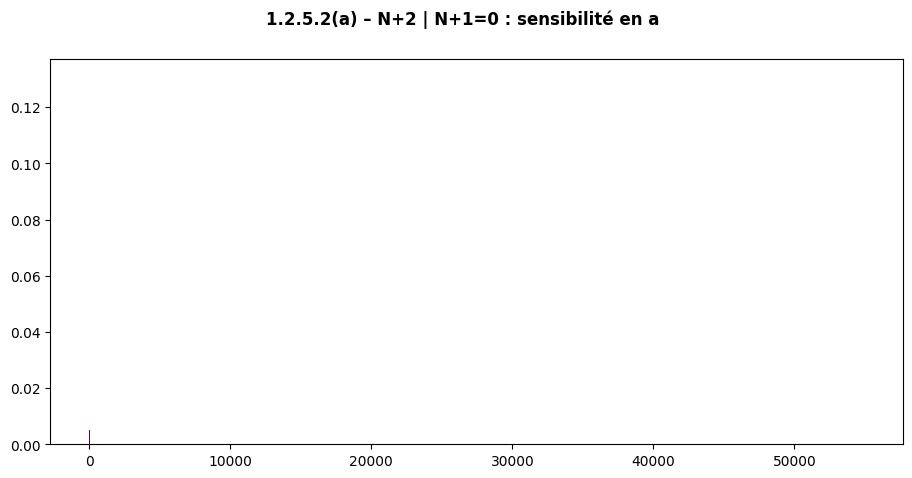

In [ ]:
a_values = [0.0, 0.5, 1.0, 2.0, 5.0]
b        = 0.5
N           = 2000
LAM_PLUS_2=1.2
LAM_MINUS_2=1.5

def hawkes_une_file_2(init, mu_plus, mu_moins, alpha, beta):
    t        = 0
    q        = init
    z_plus   = 0
    z_moins  = 0
    lam_plus = mu_plus
    temps    = [t]
    tailles  = [q]
    intensites_moins = []
    departs_N1       = []
    

    while q > 0:
        lam_minus = max(0.0, mu_moins - alpha * z_plus + alpha * z_moins)
        total     = lam_plus + lam_minus
        if total <= 1e-10:
            break
        dt       = np.random.exponential(1 / total)
        z_plus  *= np.exp(-beta * dt)
        z_moins *= np.exp(-beta * dt)
        t       += dt
        if np.random.random() < lam_plus / total:
            q += 1; z_plus  += 1
        else:
            q -= 1; z_moins += 1
            departs_N1.append(t)
        temps.append(t)
        tailles.append(q)
        intensites_moins.append(lam_minus)

    return t, temps, tailles, intensites_moins, departs_N1


def simulate_second_limit_2(lam_plus, lam_minus, Q2_0, T_stop, a, b, departures_N1):
    Q       = Q2_0
    t       = 0.0
    D2      = 0.0
    dep_idx = 0
    while True:
        lp2   = max(0.0, lam_plus + D2)
        total = lp2 + lam_minus
        dt    = np.random.exponential(1.0 / total)
        if t + dt > T_stop:
            break
        t  += dt
        D2 *= np.exp(-b * dt)
        while dep_idx < len(departures_N1) and departures_N1[dep_idx] <= t:
            D2 += a; dep_idx += 1
        lp2   = max(0.0, lam_plus + D2)
        total = lp2 + lam_minus
        if np.random.random() < lp2 / total:
            Q += 1
        else:
            Q = max(0, Q - 1)
    return Q


simulations = []
N2_marginal = []
for _ in range(N):
    T, _, _, _,_,dep_Nm1 = hawkes_une_file_2(Q_ASK, MU_PLUS, MU_MINUS, ALPHA, BETA)
    simulations.append((T, dep_N1))          
    N2_marginal.append(simulate_second_limit_2(
        LAM_PLUS_2, LAM_MINUS_2, Q2_0, T, 0.0, b, dep_N1))

all_N2 = {}
for a in a_values:
    all_N2[a] = [simulate_second_limit_2(
                    LAM_PLUS_2, LAM_MINUS_2, Q2_0, T, a, b, dep_N1)
                 for T, dep_N1 in simulations]

toutes_valeurs = N2_marginal + [v for vals in all_N2.values() for v in vals]
bins = np.arange(0, max(toutes_valeurs) + 2) - 0.5

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("1.2.5.2(a) – N+2 | N+1=0 : sensibilité en a", fontweight="bold")

ax.hist(N2_marginal, bins=bins, density=True, color="gray", alpha=0.4,
        rwidth=0.8, label="Marginale (a=0)")

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(a_values)))
for a, color in zip(a_values, colors):
    ax.hist(all_N2[a], bins=bins, density=True, alpha=0.4, color=color,
            label=f"a={a}  (moy={np.mean(all_N2[a]):.1f})")

ax.set(xlabel="N+2", ylabel="Densité",
       title=f"Conditionnelle N+2 | N+1=0  vs Marginale  (n={N})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
simulations = []
N2_marginal = []
for _ in range(N):
    T, _, _, _, dep_Nm1 = hawkes_une_file_2(Q_BID, MU_PLUS, MU_MINUS, ALPHA, BETA)
    simulations.append((T, dep_N1))          
    N2_marginal.append(simulate_second_limit_2(
        LAM_PLUS_2, LAM_MINUS_2, Q2_0, T, 0.0, b, dep_Nm1))

all_N2 = {}
for a in a_values:
    all_N2[a] = [simulate_second_limit_2(
                    LAM_PLUS_2, LAM_MINUS_2, Q2_0, T, a, b, dep_Nm1)
                 for T, dep_Nm1 in simulations]

toutes_valeurs = N2_marginal + [v for vals in all_N2.values() for v in vals]
bins = np.arange(0, max(toutes_valeurs) + 2) - 0.5

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("1.2.5.2(a) – N+2 | N-1=0 : sensibilité en a", fontweight="bold")

ax.hist(N2_marginal, bins=bins, density=True, color="gray", alpha=0.4,
        rwidth=0.8, label="Marginale (a=0)")

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(a_values)))
for a, color in zip(a_values, colors):
    ax.hist(all_N2[a], bins=bins, density=True, alpha=0.4, color=color,
            label=f"a={a}  (moy={np.mean(all_N2[a]):.1f})")

ax.set(xlabel="N+2 ", ylabel="Densité",
       title=f"Conditionnelle N+2 | N-1=0  vs Marginale  ")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()